# Robust Q Learning, Example: Comparison with KL

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import copy 
import random
import pandas as pd
from tqdm import tqdm
from scipy.optimize import minimize
from scipy.stats import randint
import matplotlib.pyplot as plt
from Q_learning import *

Adopt the Setting

In [2]:
h = 1 # holding cost
p = 2 # per unit lost sales penalty
k = 3 # fixed ordering cost
n = 10 # Size of the State Space

# State Space
X = np.arange(-n,n+1,1)

#Action Space
A = np.arange(0,n+1,1)

# Reward
def r(x,a,y):
    return (-(k*(a>0)+h*y*(y>0)+p*(-y)*(y<0)))*(a<=n-x*(x>0)) - 10*(a>n-x*(x>0)) # Penalizing if not in the action set

# Generation of the next state
def P_0(x,a):
    if (a>n-x*(x>0)):
        return x # Do not change the state if the chosen action is not allowed
    else:
        return x*(x>0)+a-randint.rvs(0, n+1,  size=1)
    
# pdf of the next state
def p_0(k,x,a):
    if (a>n-x*(x>0)):
        return 1*(k==x)
    else:
        return (1/(n+1))*(k<= x*(x>0)+a )*(k>= x*(x>0)+a -n)
    
# Adopt Parameters from the  Paper

alpha = 0.9 # Discount Factor
x_0 = np.array(0) #Initial Value

# 1) Non-Robust

Run the non-robust Q-Learning Algorithm

In [3]:
Q_opt_nonrobust = q_learning(X,
               A,
               r,
               P_0, # Simulation of next state in dependence of x and a
               alpha,
               x_0, 
               eps_greedy = 0.01,
               Nr_iter = 50000,
               gamma_t_tilde = lambda t: 1/(1+(1-alpha)*(t-1)),
                Q_0 = np.ones([len(X),len(A)]))

100%|██████████| 50000/50000 [00:11<00:00, 4187.61it/s]


In [4]:
if np.ndim(X)>1:
    X_list = X
else:
    X_list = np.array([[x] for x in X])
def x_index(x):
    return np.flatnonzero((x==X_list).all(1))[0]
def a_opt_nonrobust(x):
    return A[np.argmax(Q_opt_nonrobust[x_index(x),:])]

In [5]:
for x in range(10):
    print("State: {}, Action: {}".format(x,a_opt_nonrobust(x)))

State: 0, Action: 8
State: 1, Action: 7
State: 2, Action: 6
State: 3, Action: 0
State: 4, Action: 0
State: 5, Action: 0
State: 6, Action: 0
State: 7, Action: 0
State: 8, Action: 0
State: 9, Action: 0


# 2) Robust

In [6]:
def c(x,y):
    return np.linalg.norm(x-y)
Nr_iter = 50000
epsilon_set = [0.5,1]

Q_list = []
a_robust_list = []

In [7]:
for epsilon in epsilon_set:    
    Q_opt_robust= robust_q_learning(X,
                   A,
                   r,
                   c,
                   P_0, # Simulation of next state in dependence of x and a
                   p_0, # The probability mass function
                   epsilon = epsilon, #epsilon
                   alpha=alpha,
                   x_0 =x_0, 
                   eps_greedy = 0.01,
                   Nr_iter = Nr_iter,
                   q =1,
                   gamma_t_tilde = lambda t: 1/(1+(1-alpha)*(t-1)),
                   Q_0 = np.ones([len(X),len(A)]))
    Q_list.append(Q_opt_robust)
    def a_opt_robust(x):
        return A[np.argmax(Q_opt_robust[x_index(x),:])]
    a_robust_list.append(a_opt_robust)

100%|██████████| 50000/50000 [12:30:53<00:00,  1.11it/s]  


In [8]:
for i in range(len(epsilon_set)):
    print("\nEpsilon = {} \n".format(epsilon_set[i]))
    for x in range(10):
        print("State: {}, Action: {}".format(x,a_robust_list[i](x)))


Epsilon = 0.5 

State: 0, Action: 8
State: 1, Action: 7
State: 2, Action: 5
State: 3, Action: 5
State: 4, Action: 0
State: 5, Action: 0
State: 6, Action: 0
State: 7, Action: 0
State: 8, Action: 0
State: 9, Action: 0

Epsilon = 1 

State: 0, Action: 8
State: 1, Action: 7
State: 2, Action: 5
State: 3, Action: 5
State: 4, Action: 0
State: 5, Action: 0
State: 6, Action: 0
State: 7, Action: 0
State: 8, Action: 0
State: 9, Action: 0


# Evaluate the strategies

In [13]:
def a_wasserstein(s):
    if s == 0:
        return 8
    elif s == 1:
        return 7
    elif s== 2:
        return 5
    elif s== 3:
        return 5
    else:
        return 0
def a_KL(s):
    if (s <= 4)*(s>=0):
        return 7 - s
    else:
        return 0

def a_non_robust(s):
    if (s <= 2)*(s>=0):
        return 8-s
    else:
        return 0

In [14]:
def simulate(N_iterations,a_strat,m=5,b=1):
    total_reward = 0
    # simulate next state
    elements =  np.linspace(0,n,n+1)
    probabilities = [(n-1-2*b)/(n**2-1)]*(n+1)
    probabilities[int(m)] = (b+1)/(n+1)
    probabilities[int(m)+1] = (b+1)/(n+1)
    def P(x,a):
        y = x+a-np.random.choice(elements, 1, p=probabilities)
        return y
    
    # Initial Value
    x = x_0
    for iter in range(N_iterations):
        x_next = P(x*(x>0),a_strat(x*(x>0)))
        total_reward += r(x,a_strat(x*(x>0)),x_next)
        x = x_next
    return -total_reward/N_iterations

Create Graphs as in the paper

In [23]:
N_iterations = 100000
b = 1
results_KL = []
results_Wasserstein = []
results_non_robust = []
for m in np.linspace(0,n-1,n):
    results_KL.append(simulate(N_iterations,a_KL,m=m,b=b))
    results_non_robust.append(simulate(N_iterations,a_non_robust,m=m,b=b))
    results_Wasserstein.append(simulate(N_iterations,a_wasserstein,m=m,b=b))

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


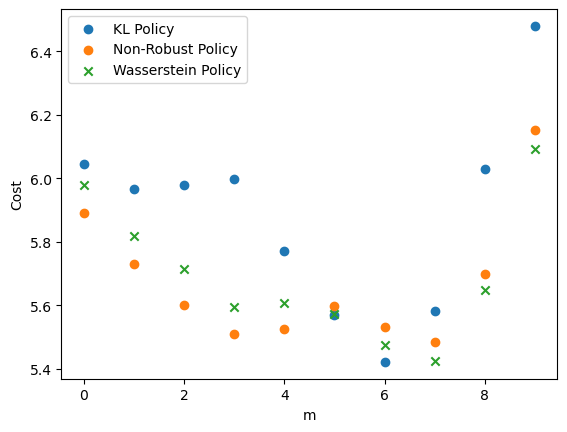

In [24]:
plt.scatter(np.linspace(0,n-1,n),results_KL,label = "KL Policy")
plt.scatter(np.linspace(0,n-1,n),results_non_robust,label = "Non-Robust Policy")
plt.scatter(np.linspace(0,n-1,n),results_Wasserstein,label = "Wasserstein Policy",marker = "x")
plt.xlabel("m")
plt.ylabel("Cost")
plt.legend()
plt.savefig('KL_Example.pdf', format='pdf',bbox_inches='tight')
plt.savefig('KL_Example.eps', format='eps',bbox_inches='tight')
plt.show()